In [56]:
import pandas as pd
import openpyxl
import os
import glob, re
import matplotlib.pyplot as plt
import functions as f

In [57]:
path = "model_Fe_Si_B_260311/**/test_res/*_test.xlsx"
files = glob.glob(path, recursive=True)

In [58]:
df = f.read_excel(files, 'errors')
df = df[['id', 'epochs']+[c for c in df.columns if c not in ['id', 'epochs']]]
df

,id,epochs,error,rmse,mae,r2,model
0,scmace_nofe8b4,100,test_energy,182.857256,111.988795,0.768530,model_rnd_e_scmace_nofe8b4_lr0.0001_100_10_test
1,scmace_nofe8b4,100,train_energy,152.843047,87.474704,0.826808,model_rnd_e_scmace_nofe8b4_lr0.0001_100_10_test
2,scmace_nofe8b4,100,test_force,481.067536,273.399745,0.970672,model_rnd_e_scmace_nofe8b4_lr0.0001_100_10_test
3,scmace_nofe8b4,100,train_force,359.272682,271.715308,0.983527,model_rnd_e_scmace_nofe8b4_lr0.0001_100_10_test
4,scmace,100,test_energy,210.180375,124.774518,0.760373,model_rnd_e_scmace_lr0.0001_100_10_test
...,...,...,...,...,...,...,...
331,scmace,40,train_force,484.112120,337.015408,0.969717,model_rnd_e_scmace_lr0.0001_40_10_test
332,scmace_nofe8b4,90,test_energy,188.963887,116.325404,0.752811,model_rnd_e_scmace_nofe8b4_lr0.0001_90_10_test
333,scmace_nofe8b4,90,train_energy,158.415401,90.712991,0.813950,model_rnd_e_scmace_nofe8b4_lr0.0001_90_10_test
334,scmace_nofe8b4,90,test_force,508.495849,287.577999,0.967233,model_rnd_e_scmace_nofe8b4_lr0.0001_90_10_test


In [59]:
#voy a generar un dataframe para cada modelo
scmace = df.query('id == "scmace"')
#matpes = df.query('id == "matpes"')
matpes = df.query('id == "matpes" & epochs != [500, 150]') #esto es ahorita que no quiero ver el de 500 epochs
scmace_nofe8b4 = df.query('id == "scmace_nofe8b4"')
matpes_nofe8b4 = df.query('id == "matpes_nofe8b4"')
#matpes_nofe8b4_freeze = df.query('id == "matpes_nofe8b4_freeze"')
matpes_nofe8b4_freeze4 = df.query('id == "matpes_nofe8b4_freeze_4"')
matpes_nofe8b4_freeze6 = df.query('id == "matpes_nofe8b4_freeze_6"')

MAE and RMSE for energy

In [60]:
#f.plot_global_error([scmace, scmace_nofe8b4, matpes, matpes_nofe8b4], ['mae'], ['scmace', 'scmace_nofe8b4', 'matpes', 'matpes_nofe8b4'], ['Test data', 'Train data'], 'energy')

In [61]:
#f.plot_global_error([scmace, scmace_nofe8b4, matpes, matpes_nofe8b4], ['mae'], ['scmace', 'scmace_nofe8b4', 'matpes', 'matpes_nofe8b4'], ['Test data', 'Train data'], 'force')

In [62]:
#f.plot_global_error([scmace, scmace_nofe8b4, matpes, matpes_nofe8b4], ['rmse'], ['scmace', 'scmace_nofe8b4', 'matpes', 'matpes_nofe8b4'], ['Test data', 'Train data'], 'force')

In [63]:
#f.plot_global_error([scmace, scmace_nofe8b4], ['mae', 'rmse'], ['scmace', 'scmace_nofe8b4'], ['Test data', 'Train data'], 'energy')

In [83]:
#f.plot_global_error([scmace, scmace_nofe8b4], ['mae', 'rmse'], ['scmace', 'scmace_nofe8b4'], ['Test data', 'Train data'], 'force')

In [84]:
#f.plot_global_error([matpes, matpes_nofe8b4], ['mae', 'rmse'], ['matpes', 'matpes_nofe8b4'], ['Test data', 'Train data'], 'energy')

Comparison between fine tuning and freeze tuning

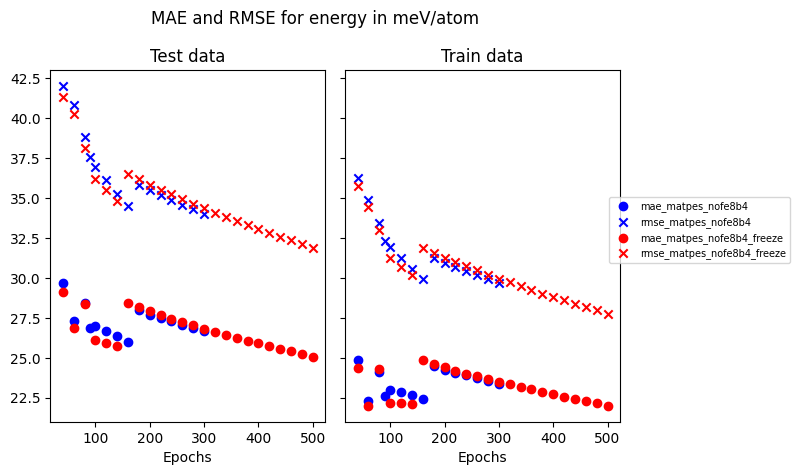

In [85]:
f.plot_global_error([matpes_nofe8b4, matpes_nofe8b4_freeze4], ['mae', 'rmse'], ['matpes_nofe8b4', 'matpes_nofe8b4_freeze'], ['Test data', 'Train data'], 'energy')

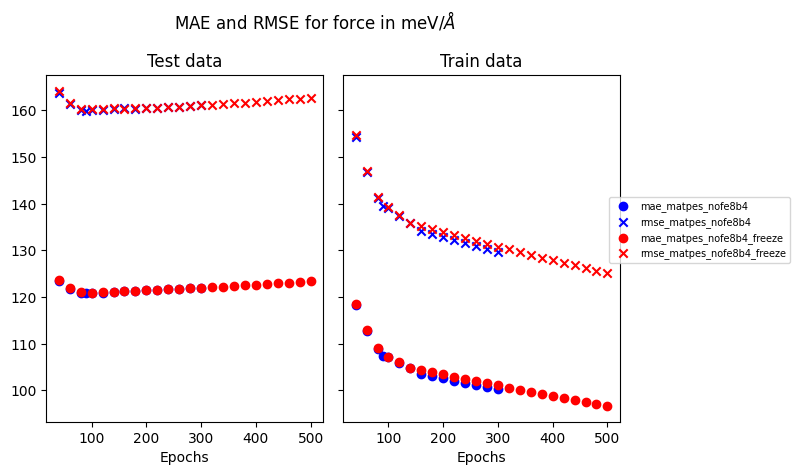

In [86]:
f.plot_global_error([matpes_nofe8b4, matpes_nofe8b4_freeze4], ['mae', 'rmse'], ['matpes_nofe8b4', 'matpes_nofe8b4_freeze'], ['Test data', 'Train data'], 'force')

In [88]:
#matpes_nofe8b4_freeze6

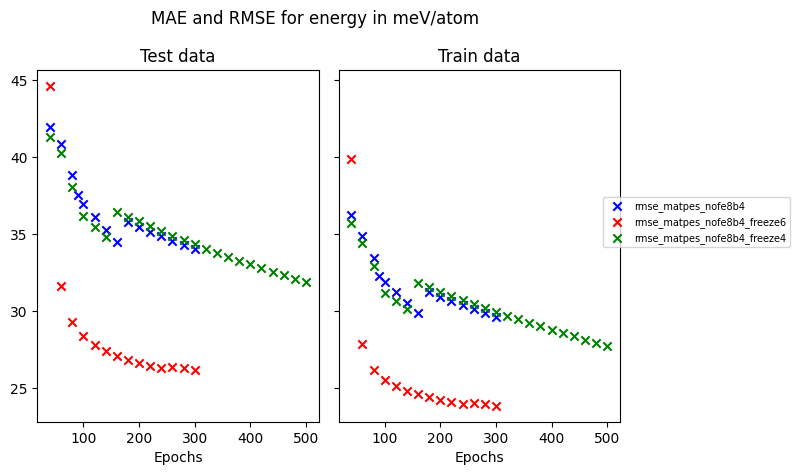

In [95]:
error_type = ['rmse']
value = 'energy'
models = [matpes_nofe8b4, matpes_nofe8b4_freeze6, matpes_nofe8b4_freeze4]
f.plot_global_error(models, error_type, ['matpes_nofe8b4', 'matpes_nofe8b4_freeze6', 'matpes_nofe8b4_freeze4'], ['Test data', 'Train data'], value)

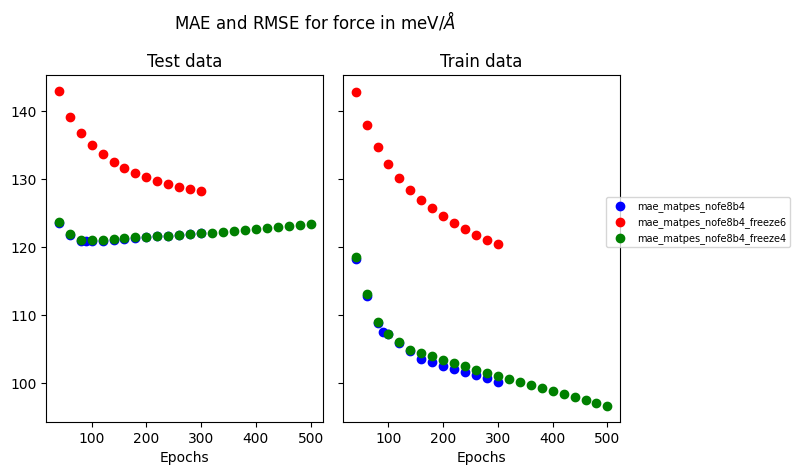

In [94]:
error_type = ['mae']
value = 'force'
models = [matpes_nofe8b4, matpes_nofe8b4_freeze6, matpes_nofe8b4_freeze4]
f.plot_global_error(models, error_type, ['matpes_nofe8b4', 'matpes_nofe8b4_freeze6', 'matpes_nofe8b4_freeze4'], ['Test data', 'Train data'], value)

In [91]:
#err_comparison = pd.concat([matpes_nofe8b4.query('epochs == 80'),matpes_nofe8b4_freeze.query('epochs == 80')])
err_comparison = pd.concat([matpes_nofe8b4, matpes_nofe8b4_freeze4])
#err_comparison = err_comparison.drop(columns=['epochs'])
#err_comparison

In [72]:
#err_comparison.query('error == ["test_energy","train_energy"]')
err_comparison.query('error == "test_energy"').sort_values('rmse', ascending=True)

,id,epochs,error,rmse,mae,r2,model
288,matpes_nofe8b4_freeze,260,test_energy,26.166566,21.613483,0.995260,model_rnd_e_matpes_nofe8b4_freeze_lr0.0001_260...
168,matpes_nofe8b4_freeze,300,test_energy,26.200771,21.542915,0.995248,model_rnd_e_matpes_nofe8b4_freeze_lr0.0001_300...
104,matpes_nofe8b4_freeze,280,test_energy,26.298383,21.588106,0.995212,model_rnd_e_matpes_nofe8b4_freeze_lr0.0001_280...
172,matpes_nofe8b4_freeze,240,test_energy,26.302457,21.722860,0.995211,model_rnd_e_matpes_nofe8b4_freeze_lr0.0001_240...
220,matpes_nofe8b4_freeze,220,test_energy,26.455310,21.869462,0.995155,model_rnd_e_matpes_nofe8b4_freeze_lr0.0001_220...
300,matpes_nofe8b4_freeze,200,test_energy,26.631259,22.025476,0.995090,model_rnd_e_matpes_nofe8b4_freeze_lr0.0001_200...
296,matpes_nofe8b4_freeze,180,test_energy,26.839626,22.187447,0.995013,model_rnd_e_matpes_nofe8b4_freeze_lr0.0001_180...
156,matpes_nofe8b4_freeze,160,test_energy,27.095140,22.349288,0.994918,model_rnd_e_matpes_nofe8b4_freeze_lr0.0001_160...
268,matpes_nofe8b4_freeze,140,test_energy,27.421453,22.498463,0.994795,model_rnd_e_matpes_nofe8b4_freeze_lr0.0001_140...
236,matpes_nofe8b4_freeze,120,test_energy,27.857031,22.612154,0.994628,model_rnd_e_matpes_nofe8b4_freeze_lr0.0001_120...


In [73]:
err_comparison.query('error == "test_force"').sort_values('rmse', ascending=True)

,id,epochs,error,rmse,mae,r2,model
38,matpes_nofe8b4,90,test_force,159.889238,120.829418,0.996760,model_rnd_e_matpes_nofe8b4_lr0.0001_90_10_test
14,matpes_nofe8b4,80,test_force,160.120801,120.835291,0.996751,model_rnd_e_matpes_nofe8b4_lr0.0001_80_10_test
50,matpes_nofe8b4,100,test_force,160.140061,120.888473,0.996750,model_rnd_e_matpes_nofe8b4_lr0.0001_100_10_test
90,matpes_nofe8b4,120,test_force,160.169780,120.942947,0.996749,model_rnd_e_matpes_nofe8b4_lr0.0001_120_10_test
86,matpes_nofe8b4,140,test_force,160.266164,121.057922,0.996745,model_rnd_e_matpes_nofe8b4_lr0.0001_140_10_test
74,matpes_nofe8b4,180,test_force,160.335569,121.354660,0.996742,model_rnd_e_matpes_nofe8b4_lr0.0001_180_10_test
34,matpes_nofe8b4,160,test_force,160.426310,121.222103,0.996738,model_rnd_e_matpes_nofe8b4_lr0.0001_160_10_test
66,matpes_nofe8b4,200,test_force,160.450978,121.460088,0.996737,model_rnd_e_matpes_nofe8b4_lr0.0001_200_10_test
10,matpes_nofe8b4,220,test_force,160.571648,121.569571,0.996733,model_rnd_e_matpes_nofe8b4_lr0.0001_220_10_test
18,matpes_nofe8b4,240,test_force,160.698383,121.681674,0.996727,model_rnd_e_matpes_nofe8b4_lr0.0001_240_10_test


In [74]:
err_comparison.query('error == ["test_force","train_force"]')

,id,epochs,error,rmse,mae,r2,model
10,matpes_nofe8b4,220,test_force,160.571648,121.569571,0.996733,model_rnd_e_matpes_nofe8b4_lr0.0001_220_10_test
11,matpes_nofe8b4,220,train_force,132.189518,102.116622,0.997770,model_rnd_e_matpes_nofe8b4_lr0.0001_220_10_test
14,matpes_nofe8b4,80,test_force,160.120801,120.835291,0.996751,model_rnd_e_matpes_nofe8b4_lr0.0001_80_10_test
15,matpes_nofe8b4,80,train_force,141.337187,108.850125,0.997451,model_rnd_e_matpes_nofe8b4_lr0.0001_80_10_test
18,matpes_nofe8b4,240,test_force,160.698383,121.681674,0.996727,model_rnd_e_matpes_nofe8b4_lr0.0001_240_10_test
...,...,...,...,...,...,...,...
291,matpes_nofe8b4_freeze,260,train_force,158.915951,121.893398,0.996777,model_rnd_e_matpes_nofe8b4_freeze_lr0.0001_260...
298,matpes_nofe8b4_freeze,180,test_force,173.157209,130.954654,0.996200,model_rnd_e_matpes_nofe8b4_freeze_lr0.0001_180...
299,matpes_nofe8b4_freeze,180,train_force,164.336897,125.856092,0.996553,model_rnd_e_matpes_nofe8b4_freeze_lr0.0001_180...
302,matpes_nofe8b4_freeze,200,test_force,172.257546,130.292282,0.996240,model_rnd_e_matpes_nofe8b4_freeze_lr0.0001_200...


In [75]:
#matpes.query('error == ["test_energy"]').sort_values('epochs', ascending=True)

In [76]:
print(f.min(scmace, 'mae'), f.min(matpes, 'mae'))

                                                model         mae
error                                                            
test_energy   model_rnd_e_scmace_lr0.0001_100_10_test  124.774518
test_force    model_rnd_e_scmace_lr0.0001_100_10_test  266.765534
train_energy  model_rnd_e_scmace_lr0.0001_100_10_test  104.387671
train_force   model_rnd_e_scmace_lr0.0001_100_10_test  264.249749                                                 model        mae
error                                                           
test_energy   model_rnd_e_matpes_lr0.0001_100_10_test  24.019415
test_force    model_rnd_e_matpes_lr0.0001_100_10_test   0.119892
train_energy  model_rnd_e_matpes_lr0.0001_100_10_test  23.863738
train_force   model_rnd_e_matpes_lr0.0001_100_10_test   0.105124


Reading the config errors

In [77]:
df_config =f.read_excel(files, 'config_errors')
df_config = df_config[['id', 'epochs', 'config', 'n_configs', 'mae', 'rmse', 'error', 'model']]
#df_config

In [78]:
df_config.query('id == "matpes" & epochs == 100')

,id,epochs,config,n_configs,mae,rmse,error,model
94,matpes,100,Fe12B3Si3,48,72.772737,73.184691,test_energy,model_rnd_e_matpes_lr0.0001_100_10_test
95,matpes,100,Fe12Si4,12,9.839741,10.007741,test_energy,model_rnd_e_matpes_lr0.0001_100_10_test
96,matpes,100,Fe16,11,6.880569,7.642087,test_energy,model_rnd_e_matpes_lr0.0001_100_10_test
97,matpes,100,Fe34B10Si10,133,3.642926,4.661568,test_energy,model_rnd_e_matpes_lr0.0001_100_10_test
98,matpes,100,Fe8B4,8,115.094036,115.104171,test_energy,model_rnd_e_matpes_lr0.0001_100_10_test
99,matpes,100,Fe12B3Si3,132,72.800135,73.055497,train_energy,model_rnd_e_matpes_lr0.0001_100_10_test
100,matpes,100,Fe12Si4,39,9.987663,10.192224,train_energy,model_rnd_e_matpes_lr0.0001_100_10_test
101,matpes,100,Fe16,40,8.827048,10.186386,train_energy,model_rnd_e_matpes_lr0.0001_100_10_test
102,matpes,100,Fe34B10Si10,590,3.656830,4.759407,train_energy,model_rnd_e_matpes_lr0.0001_100_10_test
103,matpes,100,Fe8B4,44,173.979772,419.412618,train_energy,model_rnd_e_matpes_lr0.0001_100_10_test


In [79]:
df.query('id == "matpes" & epochs == 100')

,id,epochs,error,rmse,mae,r2,model
44,matpes,100,test_energy,41.652997,24.019415,0.990589,model_rnd_e_matpes_lr0.0001_100_10_test
45,matpes,100,train_energy,100.094452,23.863738,0.951146,model_rnd_e_matpes_lr0.0001_100_10_test
46,matpes,100,test_force,0.159079,0.119892,0.996762,model_rnd_e_matpes_lr0.0001_100_10_test
47,matpes,100,train_force,0.136716,0.105124,0.997585,model_rnd_e_matpes_lr0.0001_100_10_test


In [80]:
#voy a generar un dataframe para cada modelo
scmace_config = df_config.query('id == "scmace"')
#matpes_config = df_config.query('id == "matpes"')
matpes_config = df_config.query('id == "matpes" & epochs != [500, 150]')
scmace_nofe8b4_config = df_config.query('id == "scmace_nofe8b4"')
matpes_nofe8b4_config = df_config.query('id == "matpes_nofe8b4"')

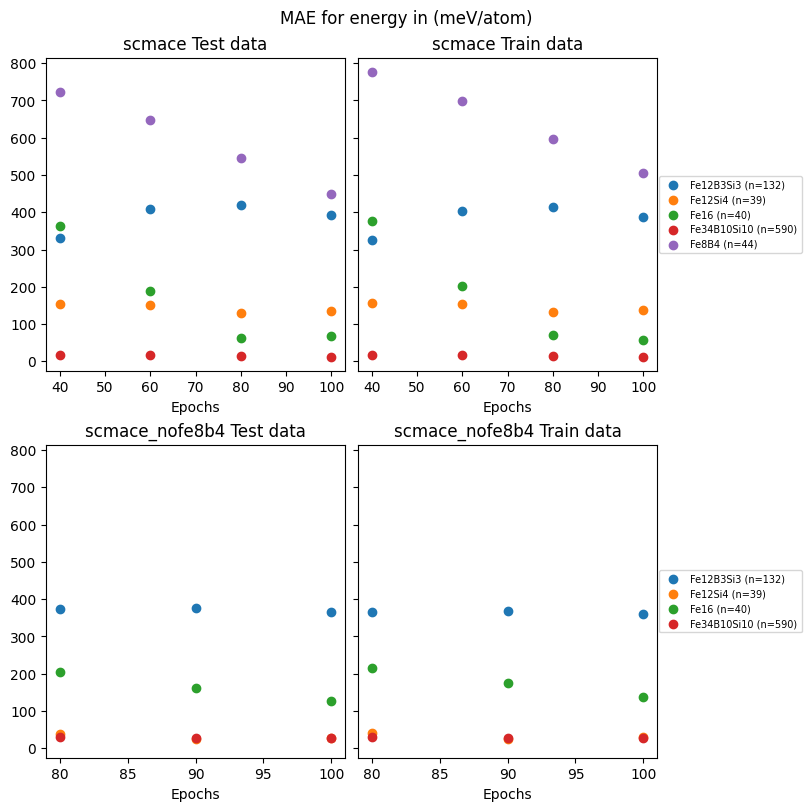

In [81]:
f.plot_config_error([scmace_config, scmace_nofe8b4_config], 'mae', ['Test data', 'Train data'], 'MAE', ['scmace', 'scmace_nofe8b4'], 'energy')

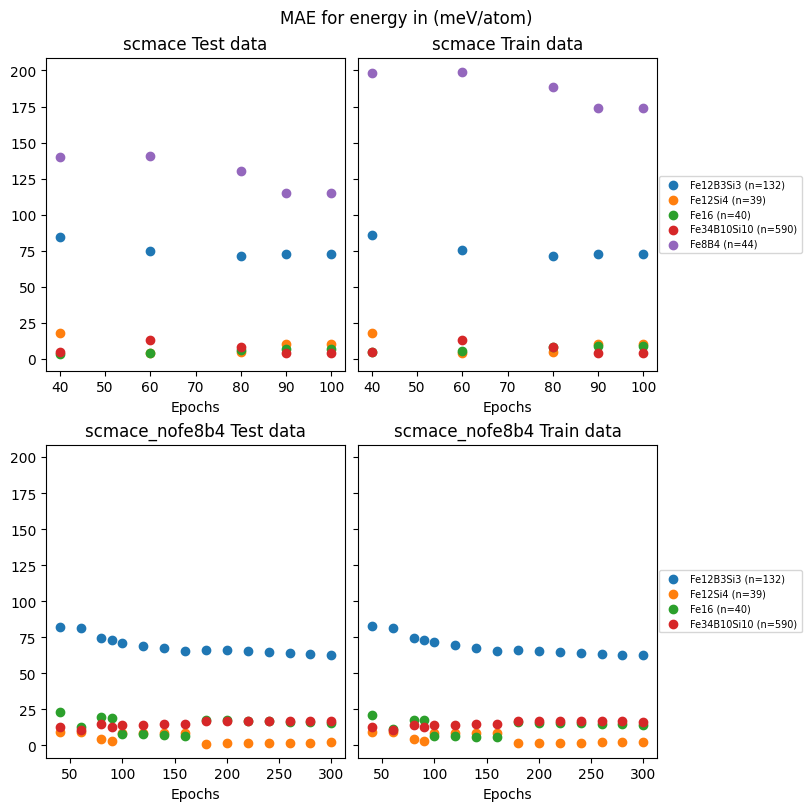

In [82]:
f.plot_config_error([matpes_config, matpes_nofe8b4_config], 'mae', ['Test data', 'Train data'], 'MAE', ['scmace', 'scmace_nofe8b4'], 'energy')